In [2]:
using DataFrames
using JLD2
using CairoMakie

In [3]:
df1 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_1_48.jld2", "ks_table");
df2 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_49_58.jld2", "ks_table");
df3 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_59_68.jld2", "ks_table");
df4 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_69_76.jld2", "ks_table");
df_big = vcat(df1, df2, df3, df4);

In [5]:
df_t = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_DDN_smag_lf.jld2", "ks_table");
for c in names(df_big)
    if !(c in names(df_t))
        df_t[!,c] = repeat(["NA"],size(df_t, 1))
    end
end

In [6]:
df_big = vcat(df_big, df_t);

In [7]:
function f(x)
    if isnothing(x)
        return NaN
    else
        return x[1]
    end
end

df_big[!,"summed_ks"] = map(f, df_big[!,"ks_dist_ensemble"]);


In [8]:
function mi(x)
    if isnothing(x)
        return NaN
    else
        return minimum(stack(x)[1,:])
    end
end

function ma(x)
    if isnothing(x)
        return NaN
    else
        return maximum(stack(x)[1,:])
    end
end

df_big[!,"ks_best_replica"] = map(mi, df_big[!,"ks_dist_replicas"]);
df_big[!,"ks_worst_replica"] = map(ma, df_big[!,"ks_dist_replicas"]);

In [9]:
x = df_big[df_big.tracking_noise .== 0.0, :]
x = x[x.model_noise .== :MVG, :]
#print(x[!,["name", "tracking_noise",	"hist_len",	"lambda", "model_noise","n_unstable","summed_ks", "ks_best_replica", "ks_worst_replica"]])
x_0 = x[(x.lambda .== "NA") .| (x.lambda .== 0.0), :];
print(x_0[!,["name", "tracking_noise",	"hist_len",	"lambda", "model_noise","n_unstable","summed_ks", "ks_best_replica", "ks_worst_replica"]])


19×9 DataFrame
 Row │ name      tracking_noise  hist_len  lambda  model_noise  n_unstable  summed_ks   ks_best_replica  ks_worst_replica 
     │ String    Float64         Int64     Any     Symbol       Any         Float64     Float64          Float64          
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ LinReg1              0.0         5  0.0     MVG          0             0.19812          0.141596          0.370516
   2 │ LinReg25             0.0        20  0.0     MVG          0             0.21629          0.169171          0.406965
   3 │ LinReg50             0.0         0  0.0     MVG          5             0.438475         0.39805           1.29547
   4 │ LinReg52             0.0         1  0.0     MVG          0             0.347861         0.252819          0.509012
   5 │ LinReg54             0.0         3  0.0     MVG          0             0.260293         0.20222           0.450714
   6 │ 

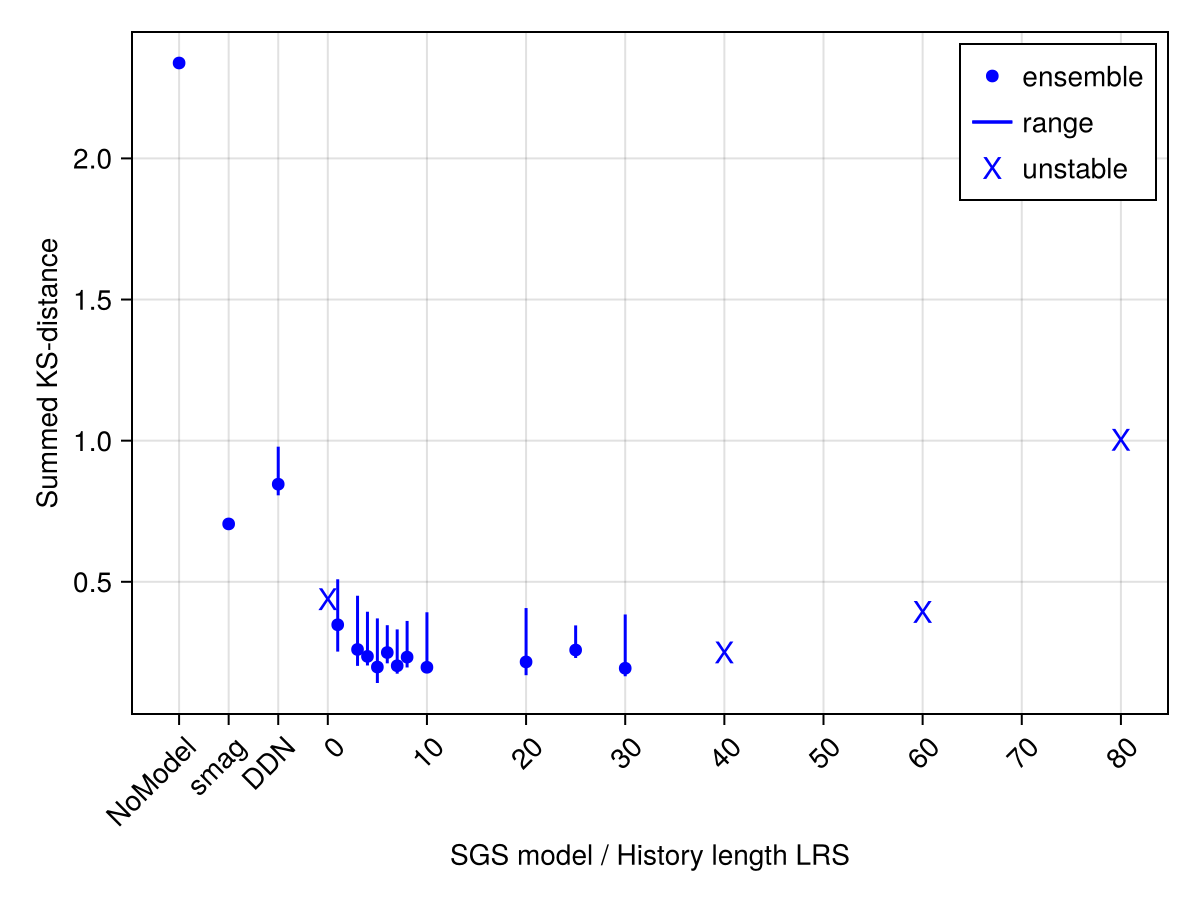

CairoMakie.Screen{PDF}


In [13]:
## plot Predictive quality of SGS models  BIG data
x = df_big[df_big.tracking_noise .== 0.0, :]
x = x[x.model_noise .== :MVG, :]
#print(x[!,["name", "tracking_noise",	"hist_len",	"lambda", "model_noise","n_unstable","summed_ks", "ks_best_replica", "ks_worst_replica"]])
x_0 = x[(x.lambda .== "NA") .| (x.lambda .== 0.0), :];

fig = Figure()
a = Axis(fig[1, 1], xticks = ([-15, -10, -5, 0, 10, 20, 30, 40, 50 ,60,70,80], ["NoModel", "smag", "DDN", "0", "10", "20", "30", "40", "50" ,"60","70","80"]), xticklabelrotation = pi/4)
x0_unstable = x_0[x_0.n_unstable .>= 1, :]
x0_stable = x_0[x_0.n_unstable .== 0, :]

scatter!(x0_stable.hist_len, x0_stable.summed_ks; color = :blue, label= "ensemble")
rangebars!(x0_stable.hist_len, x0_stable.ks_worst_replica, x0_stable.ks_best_replica; color = :blue, label= "range") 
scatter!(x0_unstable.hist_len, x0_unstable.summed_ks; color = :blue, label= "unstable", markersize = 15, marker = 'X')

axislegend(a, postion=:ct)

a.ylabel="Summed KS-distance"
a.xlabel="SGS model / History length LRS"

display(fig)
save(@__DIR__()*"/figures/bigData_KS_VS_history.pdf", fig)
#save(@__DIR__()*"/figures/history_length_notracknoise.pdf", fig)


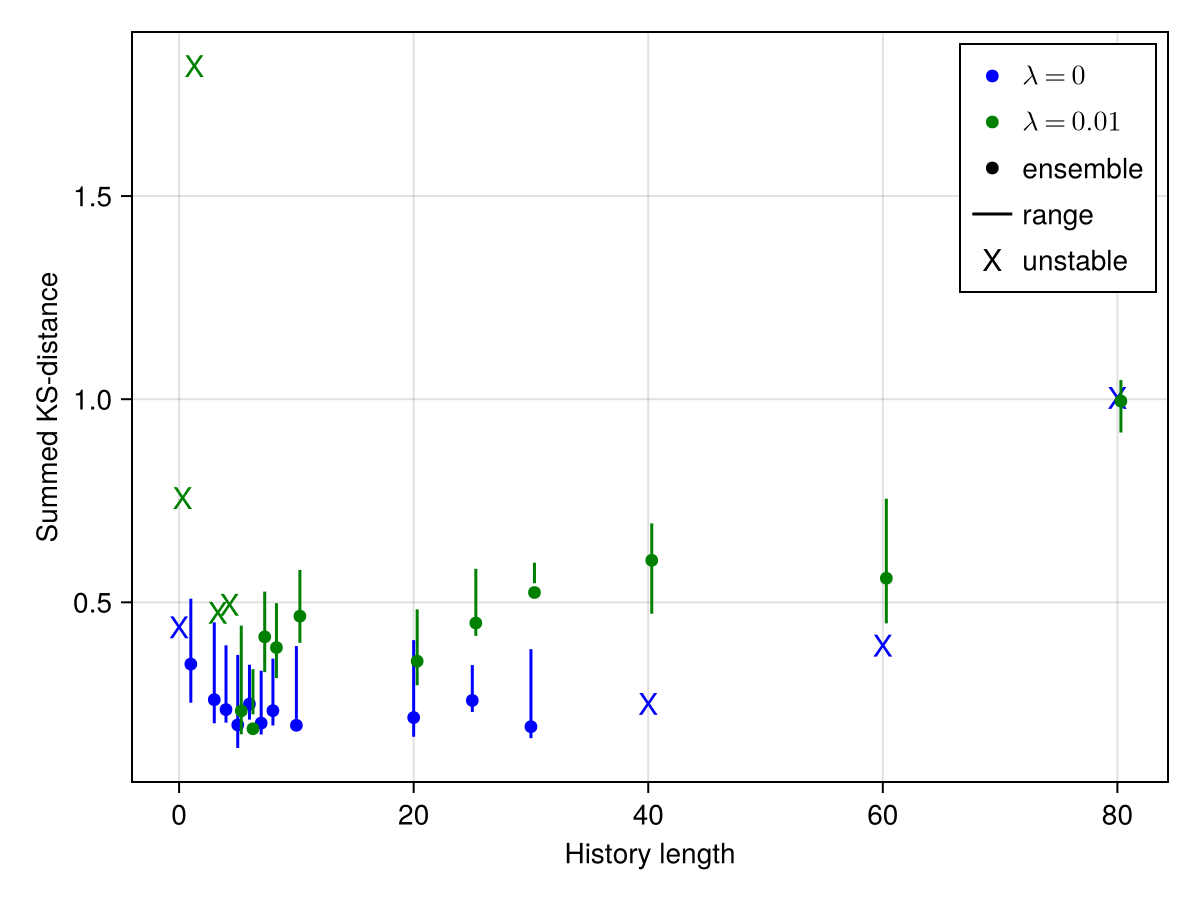

CairoMakie.Screen{PDF}


In [14]:
## plot Predictive quality of SGS models influence regularization
x = df_big[df_big.tracking_noise .== 0.0, :]
x = x[x.model_noise .== :MVG .&& x.hist_len .!= 50, :]

x_0 = x[x.lambda .== 0.0, :]
x_01 = x[x.lambda .== 0.01, :]
#print(x_01[!,["name", "tracking_noise",	"hist_len",	"lambda", "model_noise","n_unstable","summed_ks", "ks_best_replica", "ks_worst_replica"]])
x0_unstable = x_0[x_0.n_unstable .>= 1, :]
x0_stable = x_0[x_0.n_unstable .== 0, :]
x01_unstable = x_01[x_01.n_unstable .>= 1, :]
x01_stable = x_01[x_01.n_unstable .== 0, :]

fig = Figure()
a = Axis(fig[1, 1])

e=scatter!(x0_stable.hist_len, x0_stable.summed_ks; color = :blue, label= "ensemble")
r=rangebars!(x0_stable.hist_len, x0_stable.ks_worst_replica, x0_stable.ks_best_replica; color = :blue, label= "range") 
x=scatter!(x0_unstable.hist_len, x0_unstable.summed_ks; color = :blue, label= "unstable", markersize = 15, marker = 'X')

g=scatter!(x01_stable.hist_len.+0.3, x01_stable.summed_ks; color = :green, label= "ensemble")
rangebars!(x01_stable.hist_len.+0.3, x01_stable.ks_worst_replica, x01_stable.ks_best_replica; color = :green, label= "range") 
scatter!(x01_unstable.hist_len.+0.3, x01_unstable.summed_ks; color = :green, label= "unstable", markersize = 15, marker = 'X')

p = [MarkerElement(color = :black, marker = :circle)]
l = [LineElement(color = :black)]
x = [MarkerElement(color = :black, marker = 'X', markersize = 15)]
axislegend(a, [e, g, p,l,x], [L"$\lambda=0$", L"$\lambda=0.01$", "ensemble", "range", "unstable"])
a.ylabel="Summed KS-distance"
a.xlabel="History length"

display(fig)
#save(@__DIR__()*"/figures/history_length_regularization.pdf", fig)
save(@__DIR__()*"/figures/bigData_regularized_KS_VS_history.pdf", fig)

In [15]:
### small training data
df1 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_1_48.jld2", "ks_table");
df2 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_49_58.jld2", "ks_table");
df3 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_59_68.jld2", "ks_table");
df4 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_69_76.jld2", "ks_table");
df5 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_77_148.jld2", "ks_table");
df6 = load(@__DIR__()*"/output/paper_data_HIT/ks_data/ks_dists_range_149_155.jld2", "ks_table");
df_big = vcat(df1, df2, df3, df4, df5, df6);

function f(x)
    if isnothing(x)
        return NaN
    else
        return x[1]
    end
end
df_big[!,"summed_ks"] = map(f, df_big[!,"ks_dist_ensemble"]);
function mi(x)
    if isnothing(x)
        return NaN
    else
        return minimum(stack(x)[1,:])
    end
end

function ma(x)
    if isnothing(x)
        return NaN
    else
        return maximum(stack(x)[1,:])
    end
end

df_big[!,"ks_best_replica"] = map(mi, df_big[!,"ks_dist_replicas"]);
df_big[!,"ks_worst_replica"] = map(ma, df_big[!,"ks_dist_replicas"]);


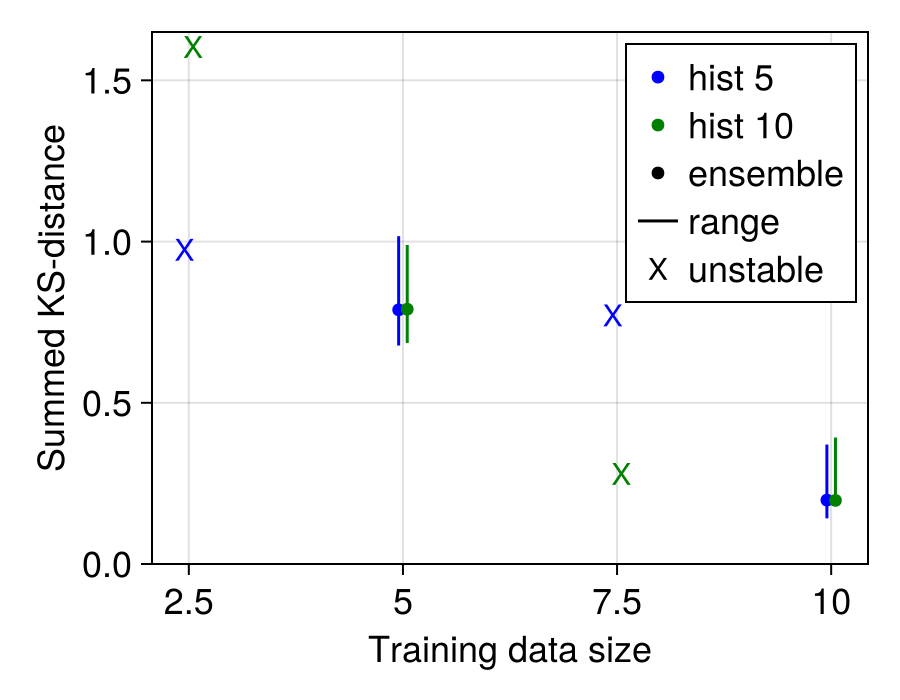

8×10 DataFrame
 Row │ name       tracking_noise  hist_len  lambda   train_range  data_size  n_unstable  summed_ks  ks_best_replica  ks_worst_replica 
     │ String     Float64         Int64     Float64  Tuple…       Float64    Any         Float64    Float64          Float64          
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ LinReg1               0.0         5      0.0  (400, 4000)       10.0  0            0.19812          0.141596          0.370516
   2 │ LinReg64              0.0        10      0.0  (400, 4000)       10.0  0            0.197235         0.213045          0.39229
   3 │ LinReg77              0.0         5      0.0  (400, 2000)        5.0  0            0.78831          0.677683          1.01657
   4 │ LinReg78              0.0         5      0.0  (400, 1000)        2.5  3            0.974445         0.697018          1.11107
   5 │ LinReg95              0.0        10     

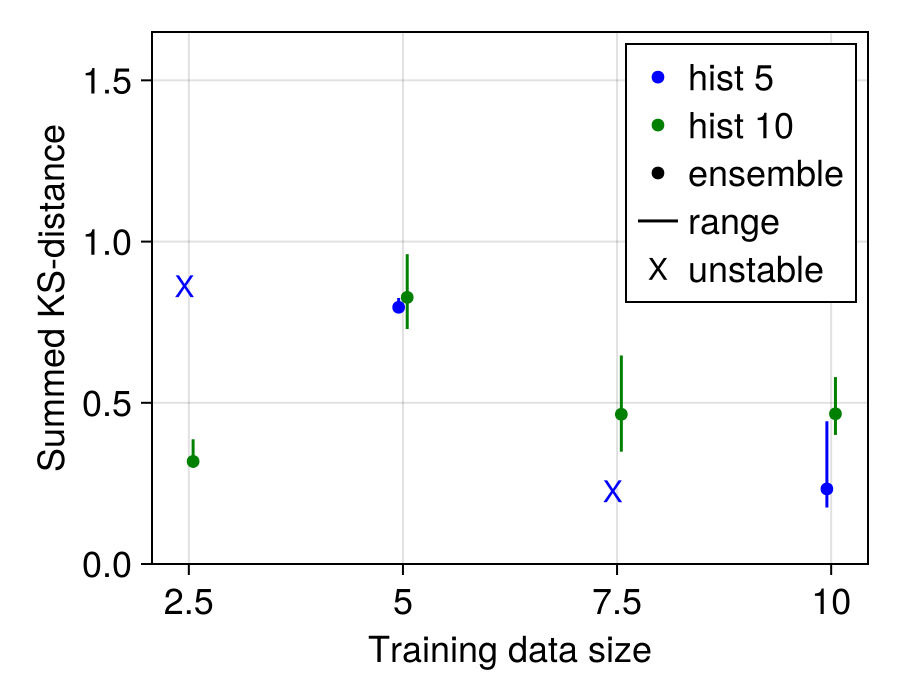

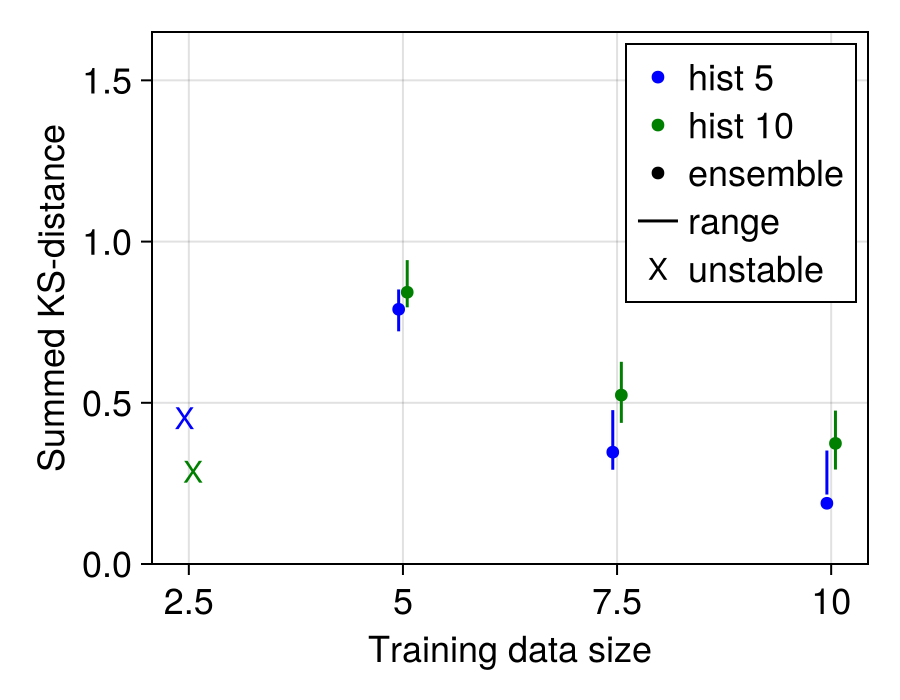

In [17]:
for lab in [0.0, 0.01, 0.1]
    x = df_big[df_big.tracking_noise .== 0.0, :]
    x = x[x.model_noise .== :MVG, :]
    x = x[x.lambda .== lab, :]
    x = x[x.hist_len .== 5 .|| x.hist_len .== 10, :]

    x.data_size = map(x -> x[2]/400, x.train_range)

    print(x[!,["name", "tracking_noise",	"hist_len",	"lambda", "train_range", "data_size","n_unstable","summed_ks", "ks_best_replica", "ks_worst_replica"]])

    x5_unstable = x[x.hist_len .== 5 .&& x.n_unstable .>= 1, :]
    x5_stable = x[x.hist_len .== 5 .&& x.n_unstable .== 0, :]
    x10_unstable = x[x.hist_len .== 10 .&& x.n_unstable .>= 1, :]
    x10_stable = x[x.hist_len .== 10 .&& x.n_unstable .== 0, :]

    fig = Figure(size=(450,350), fontsize=18)
    a = Axis(fig[1, 1])

    e=scatter!(x5_stable.data_size.-0.05, x5_stable.summed_ks; color = :blue, label= "ensemble")
    r=rangebars!(x5_stable.data_size.-0.05, x5_stable.ks_worst_replica, x5_stable.ks_best_replica; color = :blue, label= "range") 
    x=scatter!(x5_unstable.data_size.-0.05, x5_unstable.summed_ks; color = :blue, label= "unstable", markersize = 15, marker = 'X')

    g=scatter!(x10_stable.data_size.+0.05, x10_stable.summed_ks; color = :green, label= "ensemble")
    rangebars!(x10_stable.data_size.+0.05, x10_stable.ks_worst_replica, x10_stable.ks_best_replica; color = :green, label= "range")
    scatter!(x10_unstable.data_size.+0.05, x10_unstable.summed_ks; color = :green, label= "unstable", markersize = 15, marker = 'X')


    p = [MarkerElement(color = :black, marker = :circle)]
    l = [LineElement(color = :black)]
    x = [MarkerElement(color = :black, marker = 'X', markersize = 15)]
    axislegend(a, [e,g,p,l,x], ["hist 5", "hist 10", "ensemble", "range", "unstable"])
    a.ylabel="Summed KS-distance"
    a.xlabel="Training data size"
    a.xticks = ([2.5, 5, 7.5, 10], ["2.5", "5", "7.5", "10"])
    ylims!(a,(0, 1.65))
    display(fig)
    save(@__DIR__()*"/figures/KS_vs_train_size_lambda_$(lab).pdf", fig)

end

